In [1]:
# Shared setup for the modular version of the notebook.
using Arpack
using Combinatorics
using Distributions
using ITensors
using ITensorMPS
using LinearAlgebra
using Random
using SparseArrays
using SpecialFunctions
using Statistics
using Yao
using JLD2
using JSON
using PyPlot

module_path = "../src/FFGPUtils.jl"
include(module_path)
using .FFGPUtils


In [2]:
# Matplotlib setup
if isdefined(Main, :Plots)
    @warn "Plots.jl is currently loaded in this session!"
end

PyPlot.matplotlib.style.use("default")
PyPlot.matplotlib.style.use("../../config/unified_plots.mplstyle")
plot_args = JSON.parsefile("../../config/unified_plots.json")

make_kwargs(dict) = Dict(Symbol(k) => v for (k, v) in dict)

make_kwargs (generic function with 1 method)

## Notebook contents

The sections below preserve the original exploratory flow as much as possible, but the reusable definitions now live in the module file.


## Spectral / scaling / random-matrix scratch work

Assorted exploratory calculations, plotting cells, and scaling checks. This part appears to be a scratchpad within the larger notebook, so it is worth treating as exploratory rather than pipeline code.

In [3]:
nruns = 100
powers = [2, 4, 6, 8, 10]
ms = [2:2:200...]

vals = zeros(nruns, length(powers), length(ms))
for run in 1:nruns
    print("\r Running run $(run) ...")
    flush(stdout)
    for (j, m) in enumerate(ms)
        y = zeros(m,m)
        for i in 1:m, j in i+1:m
            y[i, j] = randn()
            y[j, i] = - y[i, j]
        end
        a = transpose(y) * y
        _eis = eigen(a).values
        
        tr_a = sum(_eis)
        
        for (k, pow) in enumerate(powers)
            # store directly in log scale (for numerical stability)
            vals[run, k, j] = log10(sum(_eis .^ pow)) - pow * log10(tr_a)  #sum(_eis .^ pow) / tr_a^pow
        end
    end
end

 Running run 100 ...

In [4]:
"""
    catalan_number(p)

Return the p-th Catalan number as a BigInt.
"""
function catalan_number(p::Integer)
    p >= 0 || throw(ArgumentError("p must be nonnegative"))
    return binomial(big(2p), big(p)) ÷ big(p + 1)
end

"""
    C_pow(p)

Asymptotic plateau constant for

    tr[Y'Y]^p / tr[(Y'Y)^p]  ~  1 / C_pow(p) * m^(p-1)

for a random real antisymmetric m×m Gaussian matrix Y.
Equivalently, C_pow(p) = Catalan(p).
"""
function C_pow(p::Integer)
    p >= 1 || throw(ArgumentError("p must be at least 1"))
    return catalan_number(p)
end

C_pow

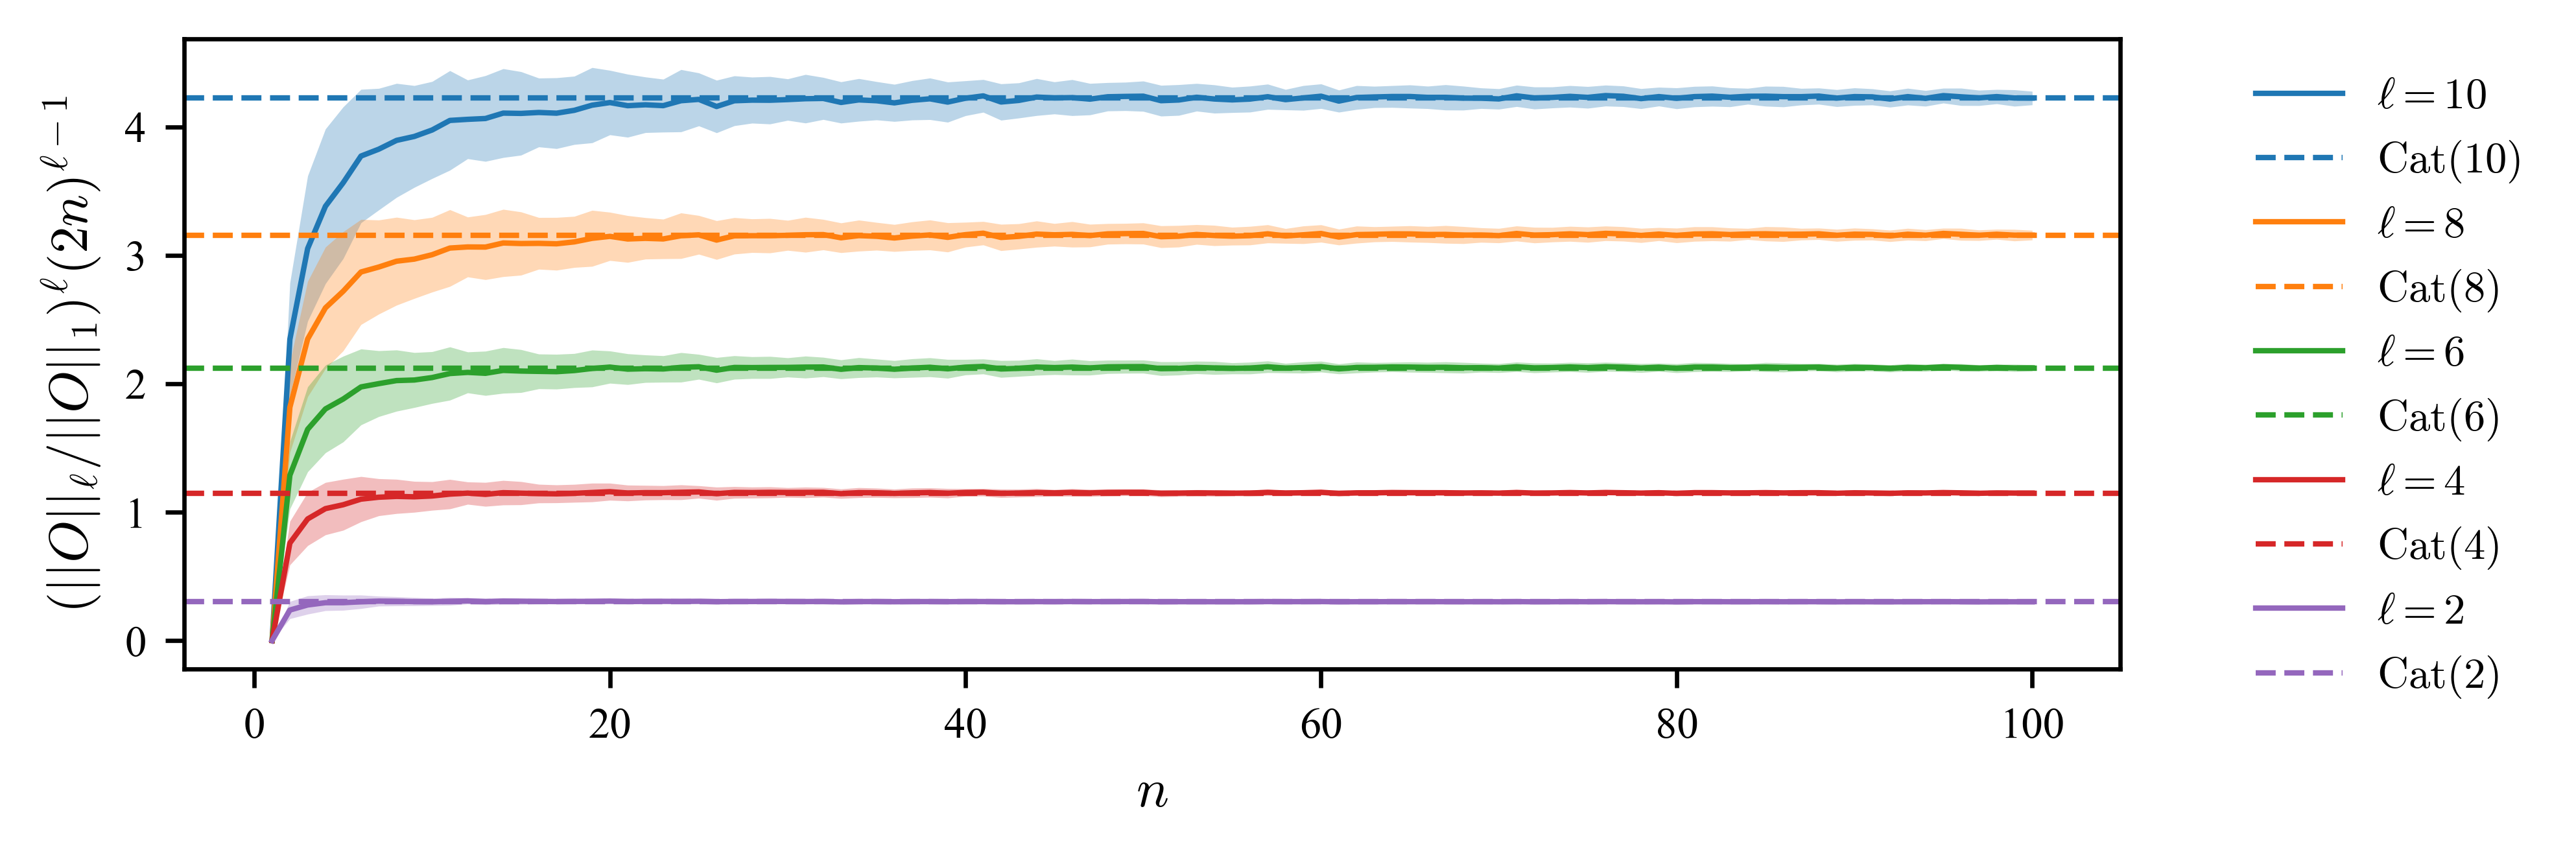

In [5]:
fig_width = plot_args["fig_width_inches_full"]
fig, ax = PyPlot.subplots(figsize=(fig_width, 2.3))

ax.set_xlabel("\$n\$")
ax.set_ylabel("\$ (\\vert\\vert O \\vert\\vert_{\\ell} / \\vert\\vert O \\vert\\vert_{1})^{\\ell}  (2n)^{\\ell-1} \$")

for (k, pow) in collect(enumerate(powers[1:end]))[end:-1:1]
    thispowdat = vals[:,k,:] .+ (pow - 1) * log10.(ms)'
    mu = mean(thispowdat, dims=1)[:]
    sig = std(thispowdat, dims=1)[:]
    
    line = ax.plot(ms ./ 2, mu, label="\$\\ell=$(pow)\$")[1]
    c = line.get_color()
    
    ax.fill_between(ms ./ 2, mu .- sig, mu .+ sig, color=c, alpha=0.3, linewidth=0)
    
    ax.axhline(y=log10(C_pow(pow)), label="\$\\mathrm{{{Cat}}}({$(pow)})\$", linestyle="--", color=c)
end

# The customized legend
ax.legend(
    loc="upper left",           # Anchor point on the legend itself
    bbox_to_anchor=(1.05, 1.0), # Place it outside the top right of the axes
    ncol=1,                     # Split into 2 columns
    frameon=false               # Remove the frame
)

# Prevents the outside legend from getting cut off when displayed or saved
fig.tight_layout() 

# Display the figure
fig

In [6]:
# Save the figure
save_dir = "../plots"
isdir(save_dir) || mkdir(save_dir)
fig.savefig(joinpath(save_dir, "ratio_m2_over_scaling.pdf"), bbox_inches="tight")

## Four-Majorana operators and Gaussian sampling

This is the main `4`-Majorana block. It contains operator builders, antisymmetric tensor utilities, ITensor/Yao sampling routines, and several numerical checks.

#### RANDOM STATE + SINGLE PAULI B4

In [7]:
using Yao

n = 12
psi = rand_state(n)
#impose parity
psi = psi + psi |> repeat(n, Z)
psi = normalize(psi)
# psi = zero_state(n)
# coeffs_vals = randn(binomial(2n, 4)) ./ sqrt(binomial(2n, 4))
coeffs_vals = zeros(binomial(2n, 4))
pauliInd = rand(1:length(coeffs_vals))
pauliComb = (collect(combinations(1:2n, 4)))[pauliInd]
coeffs_vals[pauliInd] = 1
coeffs = fill_antisymm_tensor(n, coeffs_vals);

In [8]:
# init majos
majos = four_majoranas_ops(n)
# construct Y tensor
yvals = [Yao.expect(GeneralMatrixBlock(majo), psi) for majo in majos]
y = fill_antisymm_tensor(n, yvals)
y_mat = reshape(y, (2n)^2, (2n)^2);
# y_contrib = tr(y_mat*y_mat*y_mat)

576×576 Matrix{Float64}:
 0.0   0.0          0.0          0.0         …   0.0          0.0         0.0
 0.0   0.0          0.0          0.0            -0.00373616   0.00527624  0.0
 0.0   0.0          0.0          0.0             0.00193304   0.0157514   0.0
 0.0   0.0          0.0          0.0            -0.00781397   0.0240558   0.0
 0.0   0.0          0.0          0.0            -0.00157056   0.00103315  0.0
 0.0   0.0          0.0          0.0         …   0.0152919   -0.0129284   0.0
 0.0   0.0          0.0          0.0             0.0130553    0.0317223   0.0
 0.0   0.0          0.0          0.0            -0.00771782  -0.0160917   0.0
 0.0   0.0          0.0          0.0             0.00484633  -0.0132479   0.0
 0.0   0.0          0.0          0.0             0.0241894   -0.0101353   0.0
 ⋮                                           ⋱                            ⋮
 0.0   0.00576932   0.00728385  -0.00291445      0.0          0.0         0.0
 0.0   0.00936325  -0.00943809   0.011157

In [9]:
n = 12
majos = four_majoranas_ops(n)

# check if saved via save_object("../data/big_samples_n$(n).jld2", big_samples)
if isfile("../data/big_samples_n$(n).jld2")
    big_samples = load_object("../data/big_samples_n$(n).jld2")
else
    @warn "No saved big samples found for n=$(n), generating new samples..."
    big_samples = zeros(100, 10000) 
    for k in 1:100 
        psi = rand_state(n)
        #impose parity
        psi = psi + psi |> repeat(n, Z)
        psi = normalize(psi)

        # construct Y tensor
        yvals = [Yao.expect(GeneralMatrixBlock(majo), psi) for majo in majos]
        y = fill_antisymm_tensor(n, yvals)
        y_mat = reshape(y, (2n)^2, (2n)^2);
        
        pauliInd = rand(1:length(coeffs_vals))
        pauliComb = (collect(combinations(1:2n, 4)))[pauliInd]
        
        big_samples[k, :] = sample_4_majos_singlepauli(n, y_mat, pauliComb, 10000)

        isdir("../data") || mkdir("../data")
        save_object("../data/big_samples_n$(n).jld2", big_samples)
    end
end

100×10000 Matrix{Float64}:
 -0.0339002   -0.0112087   -0.00256229  …  -0.00238173  -0.000562497
  0.0256463    0.0024115   -0.0380312       0.0110068    0.00227084
  0.00135096  -0.0075458    0.0112287       0.00642213   0.00746188
 -0.00278778   0.0409102   -0.022519       -0.0135732   -0.00337461
  0.00582933   0.0162159    0.00196574      0.0056852   -0.00787914
 -0.00223106  -0.00668303   0.011057    …  -0.0291233   -0.00478273
  0.0265429    0.00757865   0.0183974      -0.0126912   -0.0385983
 -0.00605601  -0.00650519   0.0314185      -0.0016092    0.00923193
 -0.00996746  -0.00401623   0.00790634      0.00218187  -0.0130115
  0.0116648   -0.0087028    0.017639       -0.0177529    0.015473
  ⋮                                     ⋱               
  0.0168737    0.00920895   0.0171906       0.0218126   -0.0251924
 -0.0109981   -0.00429217   0.01558        -0.0114466   -0.032692
  0.00785188   0.00976973  -0.0124034      -0.0100748    0.00356851
 -0.0110059   -0.0158378   -0.0107639 

In [10]:
# Check and load zero samples saved via save_object("../data/zero_samples_n$(n).jld2", zero_samples)
if isfile("../data/zero_samples_n$(n).jld2")
    zero_samples = load_object("../data/zero_samples_n$(n).jld2")
else
    @warn "Zero samples not found, generating new ones (this may take a while)..."
    # construct Y tensor
    yvals = [Yao.expect(GeneralMatrixBlock(majo), psi) for majo in majos]
    y = fill_antisymm_tensor(n, yvals)
    y_mat0 = reshape(y, (2n)^2, (2n)^2);

    pauliInd = rand(1:length(coeffs_vals))
    pauliComb = (collect(combinations(1:2n, 4)))[pauliInd]

    zero_samples = sample_4_majos_singlepauli(n, y_mat0, pauliComb, 10000)

    isdir("../data") || mkdir("../data")
    save_object("../data/zero_samples_n$(n).jld2", zero_samples)
end

10000-element Vector{Float64}:
  0.04552810827950367
 -0.001727552622009347
 -0.012016014262218173
  0.0728196945375089
 -0.08931559802300496
  0.029778780860869748
  0.0006073924630125415
  0.06780990407247456
  0.026707634903466997
  0.03542846933445548
  ⋮
 -0.06867794481151701
  0.09905730899134965
  0.07791546692766177
  0.007088469445798377
  0.01426716250276655
  0.065159998345858
 -0.01553705697256249
 -0.012206925935218771
  0.0009642667747836757

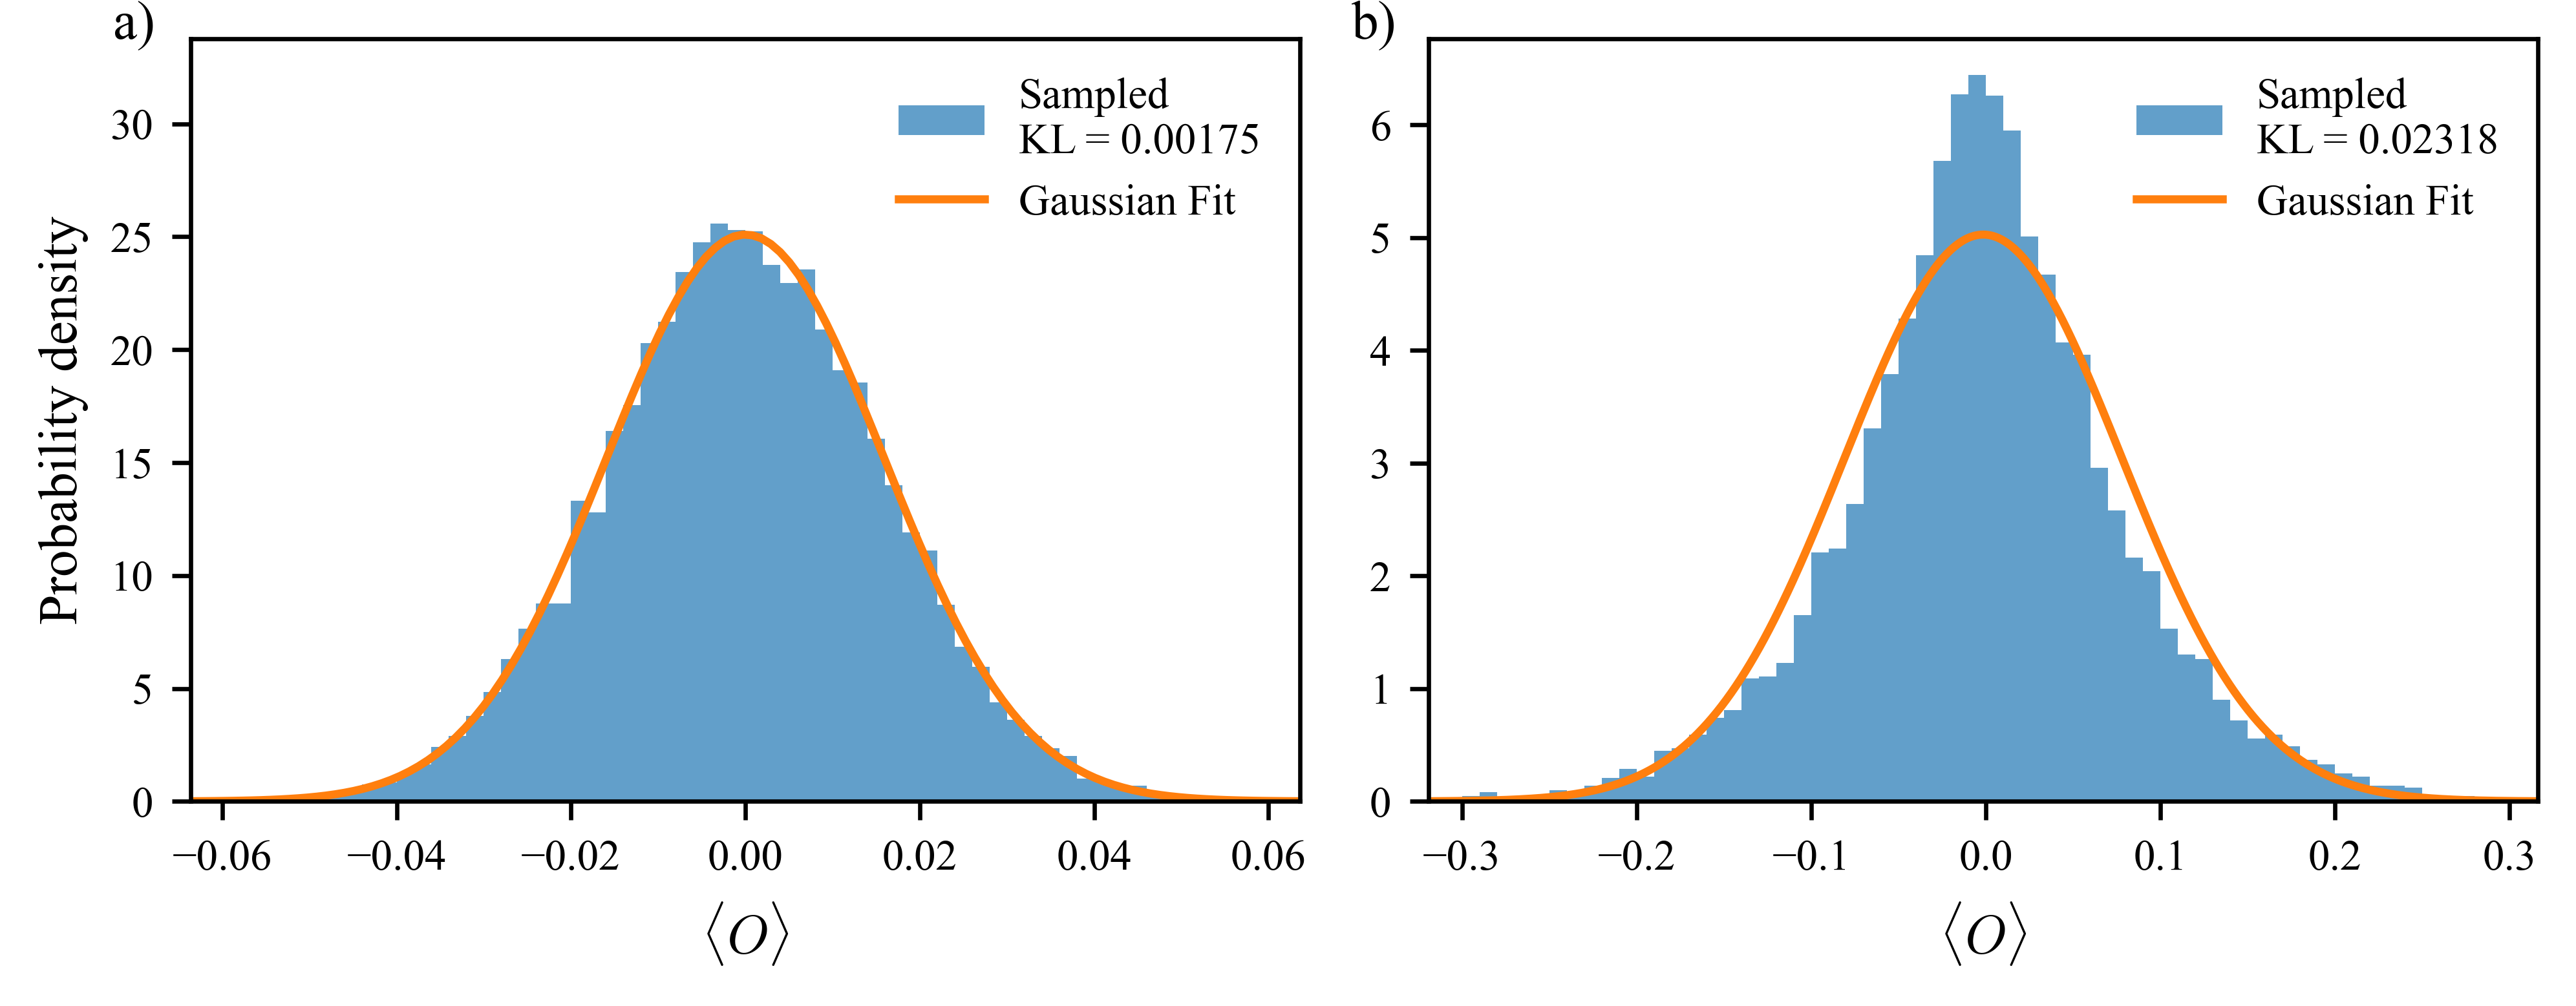

In [11]:
using PyPlot, Statistics, Distributions, StatsBase, Printf

kls = Float64[]
nbins = 100

# 1. Evaluate KL divergences for all samples
for samples in eachrow(big_samples)
    μ = mean(samples)
    σ = std(samples)
    gauss = Normal(μ, σ)
    
    h = fit(Histogram, samples, nbins=nbins)
    edges = h.edges[1]
    counts = h.weights
    N = sum(counts)
    
    p_emp = counts ./ N
    q = [cdf(gauss, edges[i+1]) - cdf(gauss, edges[i]) for i in 1:length(edges)-1]
    
    kl = sum(p_emp[i] > 0 ? p_emp[i] * log(p_emp[i] / q[i]) : 0.0 for i in eachindex(p_emp))
    push!(kls, kl)
end

# 2. Find the best run
best_idx = argmin(kls)
best_samples = big_samples[best_idx, :]
best_kl = kls[best_idx]

# 3. Process zero_samples
μ0 = mean(zero_samples)
σ0 = std(zero_samples)
gauss0 = Normal(μ0, σ0)

h0 = fit(Histogram, zero_samples, nbins=nbins)
edges0 = h0.edges[1]
counts0 = h0.weights
N0 = sum(counts0)

p0_emp = counts0 ./ N0
q0 = [cdf(gauss0, edges0[i+1]) - cdf(gauss0, edges0[i]) for i in 1:length(edges0)-1]
kl0 = sum(p0_emp[i] > 0 ? p0_emp[i] * log(p0_emp[i] / q0[i]) : 0.0 for i in eachindex(p0_emp))

# 4. Plotting
fig_width = plot_args["fig_width_inches_full"]
fig, (ax1, ax2) = subplots(1, 2, figsize=(fig_width, 2.7))

# --- Left Plot (Best Sample) ---
# Use the exact edges from the histogram fit to ensure visual matches the math
best_h = fit(Histogram, best_samples, nbins=nbins)
ax1.hist(best_samples, bins=best_h.edges[1], density=true, alpha=0.7, rasterized=false, histtype="stepfilled", linewidth=0,
         label=@sprintf("Sampled\nKL = %.5f", best_kl))

x1 = range(minimum(best_samples)-1, stop=maximum(best_samples)+1, length=2000)
best_μ = mean(best_samples)
best_σ = std(best_samples)
y1 = pdf.(Normal(best_μ, best_σ), x1)
ax1.plot(x1, y1, label="Gaussian Fit", linewidth=1.5)

x_lim_factor = 4

ax1.set_xlim(best_μ - x_lim_factor*best_σ, best_μ + x_lim_factor*best_σ)
ax1.set_ylim(0, 32)
ax1.legend(frameon=false)

ax1.set_xlabel("\$\\langle O \\rangle\$")
ax1.set_ylabel("Probability density")

default_label_size = PyPlot.matplotlib.rcParams["axes.labelsize"]
ax1.text(-0.07, 1.0, "a)", transform=ax1.transAxes, 
         fontsize=default_label_size, in_layout=false)

# --- Right Plot (Zero Sample) ---
ax2.hist(zero_samples, bins=edges0, density=true, alpha=0.7, rasterized=false, histtype="stepfilled", linewidth=0,
         label=@sprintf("Sampled\nKL = %.5f", kl0))

x0 = range(minimum(zero_samples)-1, stop=maximum(zero_samples)+1, length=2000)
y0 = pdf.(gauss0, x0)
ax2.plot(x0, y0, label="Gaussian Fit", linewidth=1.5)

ax2.set_xlim(μ0 - x_lim_factor*σ0, μ0 + x_lim_factor*σ0)
ax2.legend(frameon=false)

ax2.set_xlabel("\$\\langle O \\rangle\$")

ax2.text(-0.07, 1.0, "b)", transform=ax2.transAxes, 
         fontsize=default_label_size, in_layout=false)

# --- ALIGNMENT FITTED GAUSSIAN PEAKS ---
# 1. Force both axes to start exactly at y=0
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

# 2. Get the auto-calculated upper bound from the right plot
y0_min, y0_max = ax2.get_ylim()

# 3. Calculate the maximum heights of the two Gaussians
peak1 = maximum(y1)
peak0 = maximum(y0)

# 4. Scale the left plot's y-limit to match the peak ratio
new_y1_max = y0_max * (peak1 / peak0)
ax1.set_ylim(0, new_y1_max)

# Adjust layout so labels don't overlap, then display
fig.tight_layout()
fig

In [12]:
# Save the figure
save_dir = "../plots"
isdir(save_dir) || mkdir(save_dir)
fig.savefig(joinpath(save_dir, "histograms_comparison.pdf"), bbox_inches="tight")

## Magic-state and two-Majorana GP experiments

This block starts using `Yao` and shifts from the early B4 sanity checks into explicit magic-state style experiments and ratio studies.

In [13]:
using Yao
function get_y_magicstate(n::Int, theta::Float64)
    n4 = n÷4
    psi = zeros(ComplexF64, 2^4)
    # psi[1] = 1/2
    # psi[4] = 1/2
    # psi[13] = 1/2
    # psi[end] = exp(1im*theta)/2
    # psi[1] = 1/sqrt(2)
    # psi[end] = exp(1im*theta)/sqrt(2)
    psi[1] = cos(theta/4)
    psi[end] = sin(theta/4)
    # extent state
    state = ArrayReg(LinearAlgebra.kron([psi for _ in 1:n4]...))
    # state = normalize(state)
    y = zeros(2n, 2n)
    majos = two_majoranas_matrix(n)
    for j in 1:2n, k in j+1:2n
        y[j, k] = Yao.expect(GeneralMatrixBlock(majos[j, k]), state)
    end
    y = y - transpose(y)
    y
end

get_y_magicstate (generic function with 1 method)

In [14]:
function check_2majo_magic_ratio(n::Int, theta::Float64)
    # get y of magic
    y = get_y_magicstate(n, theta)
    # make the doubled tensor
    a = transpose(y) * y
    #get eivals
    _eis = eigen(a).values
    
    tr_a = sum(_eis)
    tr_a2 = sum(_eis .^ 2)

    return tr_a^2 / tr_a2
end

check_2majo_magic_ratio (generic function with 1 method)

In [15]:
[check_2majo_magic_ratio(n, rand()) / 2n for n in 8:4:16]

3-element Vector{Float64}:
 1.0000000000000007
 1.0000000000000009
 1.0

In [16]:
function check_2majo_magic_randmeas_gp(n::Int, theta::Float64, nsamples::Int; verbose::Bool=false)
    # get y of magic
    y = get_y_magicstate(n, theta)
    # prepare random measurement
    o = zeros(2n,2n)
    for i in 1:2n, j in i+1:2n
        o[i, j] = randn()
        o[j, i] = - o[i, j]
    end
    # get samples
    results = zeros(nsamples)
    @inbounds for i in 1:nsamples
        #sample a random orthogoal
        Q = haar_rand_o(2n)
        #apply
        results[i] = dot(transpose(o)*Q, Q*y) / 2
        if verbose
            print("\r - sampled $(i)/$(nsamples)")
            flush(stdout)
        end
    end
    results
end
    

check_2majo_magic_randmeas_gp (generic function with 1 method)

In [17]:
function check_2majo_magic_singlepauli_gp(n::Int, theta::Float64, pauliind::Tuple{Int,Int}, nsamples::Int; verbose::Bool=false)
    # get y of magic
    y = get_y_magicstate(n, theta)
    # prepare pauli measurement
    o = spzeros(2n,2n)
    c1,c2 = pauliind
    o[c1,c2] = +1
    o[c2,c1] = -1
    # get samples
    results = zeros(nsamples)
    @inbounds for i in 1:nsamples
        #sample a random orthogoal
        Q = haar_rand_o(2n)
        #apply
        results[i] = dot(transpose(o)*Q, Q*y) / 2
        if verbose
            print("\r - sampled $(i)/$(nsamples)")
            flush(stdout)
        end
    end
    results
end

check_2majo_magic_singlepauli_gp (generic function with 1 method)

In [18]:
function exact_variace_single(n::Int, theta::Float64)
    return cos(theta/2)^2 / (2n-1)
end;

function exact_variace_superpos(n::Int, theta::Float64)
    return n * cos(theta/2)^2
end;

In [19]:
using Statistics, Distributions

Random.seed!(1234)
n = 12
nsamps = 50_000
theta_min = 0
theta_max = 2pi/3
theta_len = 7
thetas = range(theta_min, theta_max, length=theta_len)

# jd_samples = [check_2majo_magic_randmeas_gp(n, θ, nsamps) for θ in thetas]
jd_samples = [check_2majo_magic_singlepauli_gp(n, θ, (1,2), nsamps) for θ in thetas]

# Global x-range across all samples
x_left  = minimum(minimum.(jd_samples)) - 1
x_right = maximum(maximum.(jd_samples)) + 1

nx = 2000
xgrid = range(x_left, x_right, length=nx)

# Store all fitted Gaussian curves
densities = Matrix{Float64}(undef, length(thetas), nx)

for (k, samples) in enumerate(jd_samples)
    μ = mean(samples)
    σ = std(samples)
    densities[k, :] = pdf.(Normal(μ, σ), xgrid)

    print("\r - $(k) done")
    flush(stdout)
end
println()

 - 7 done


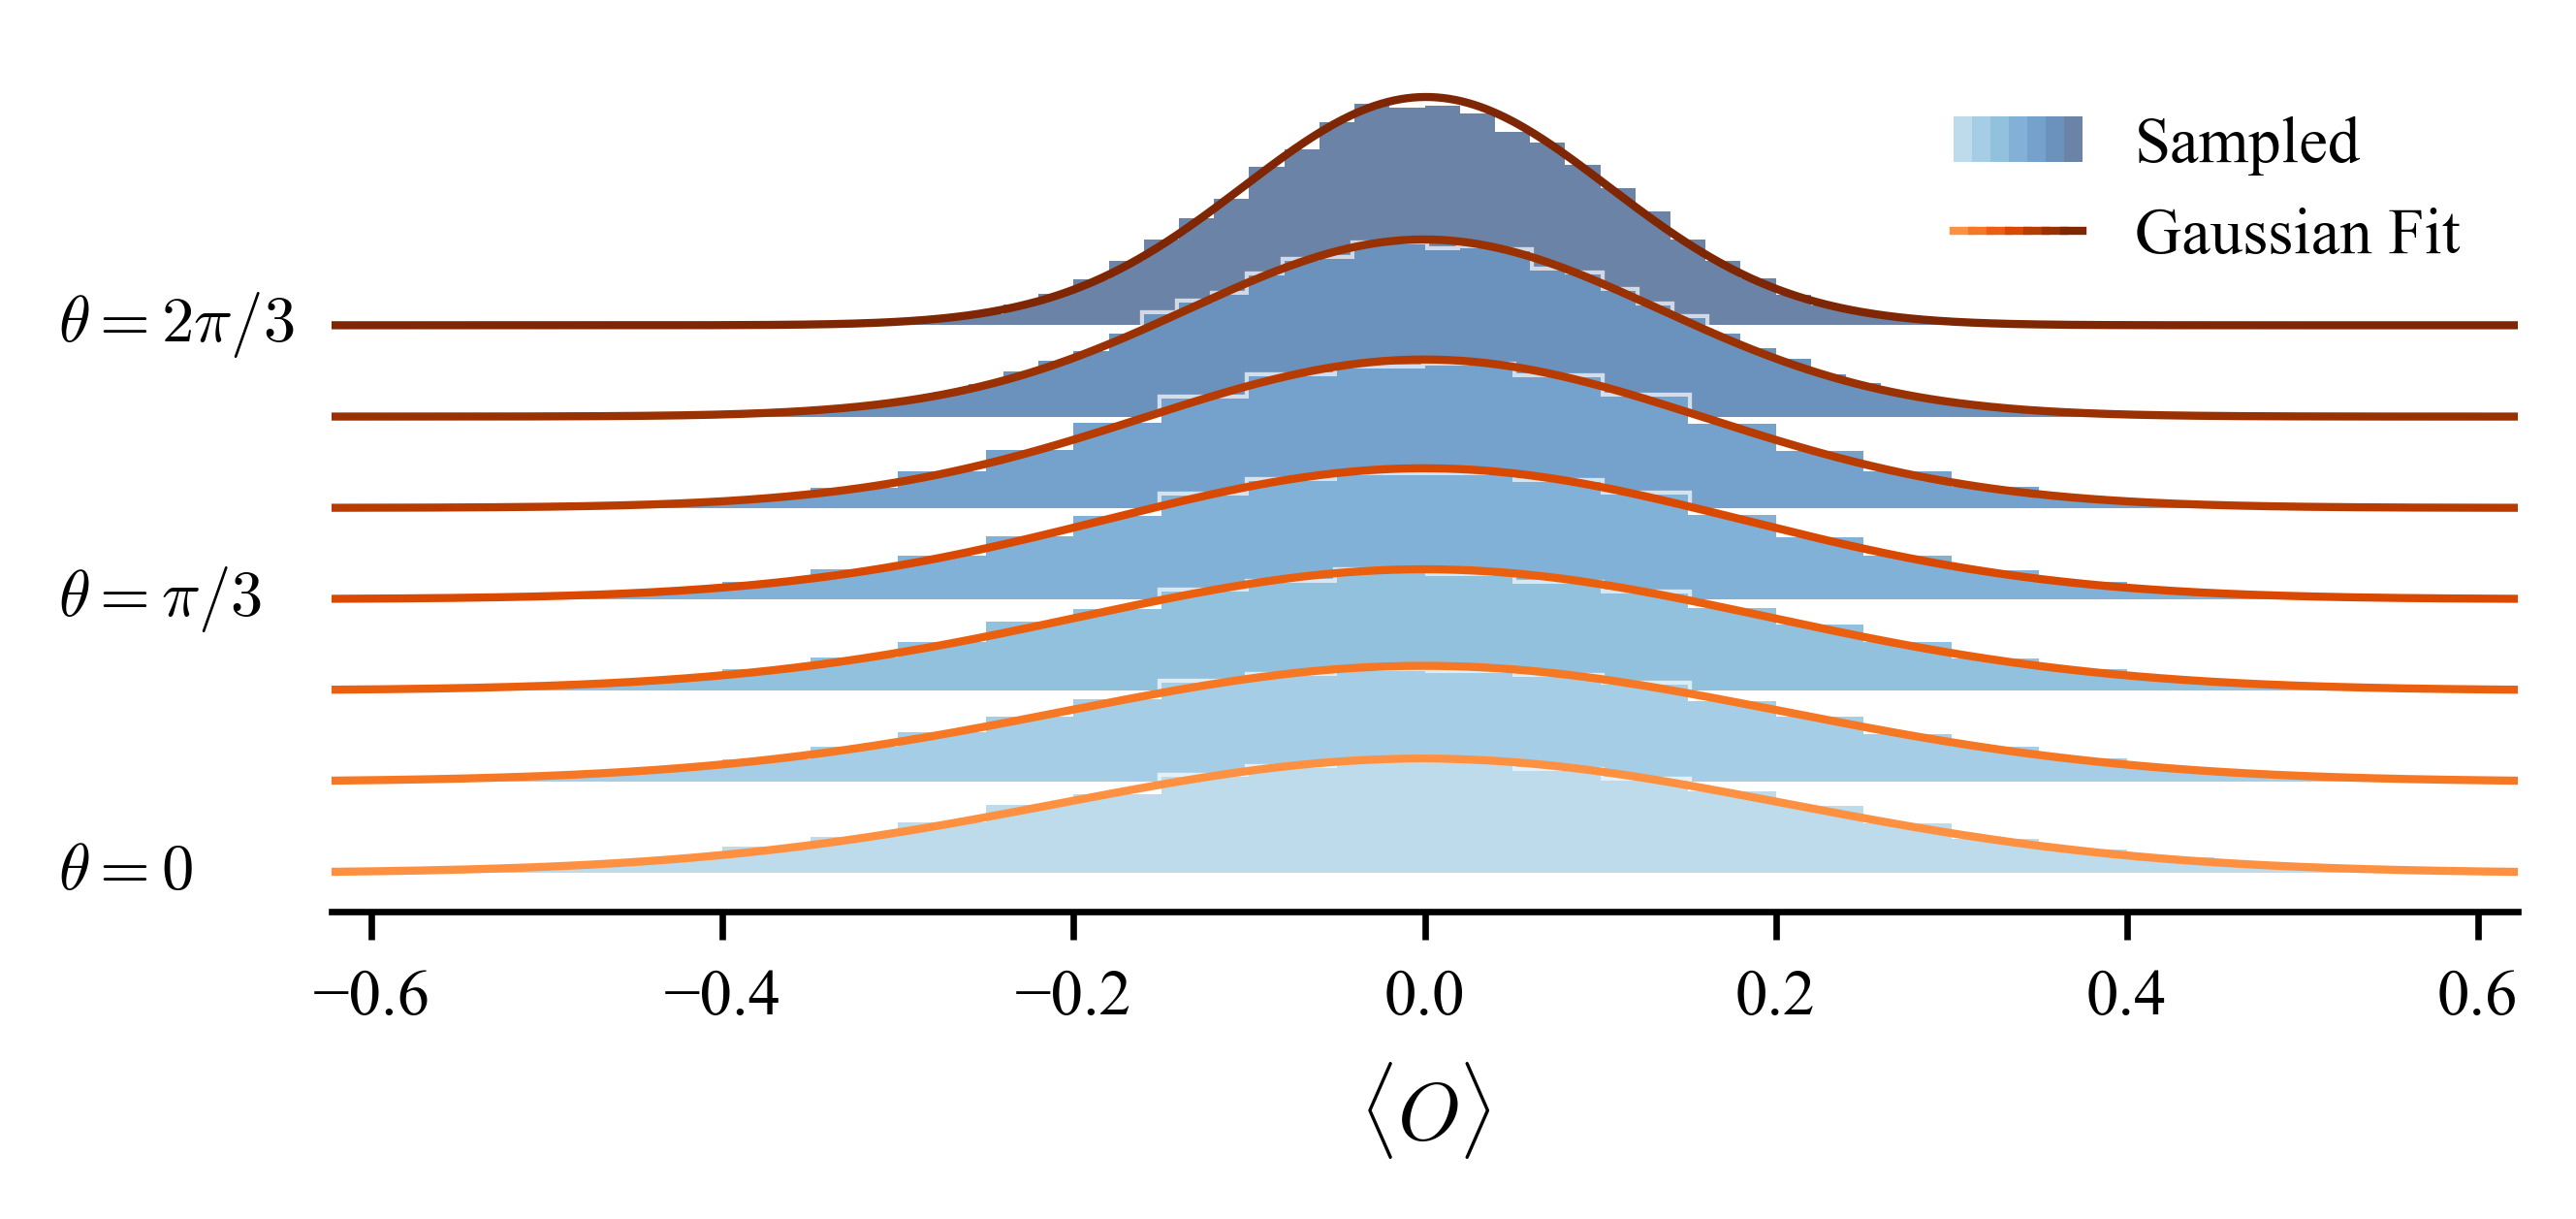

In [20]:
using PyPlot, Printf, Statistics, PyCall, StatsBase

# 1. Calculate the standard deviation of the widest distribution (theta = 0)
std_0 = std(jd_samples[1])

# Create the figure
fig_width = plot_args["fig_width_inches_full"] * (2/3)
fig, ax = PyPlot.subplots(figsize=(fig_width, 2.2))

d_theta = thetas[2] - thetas[1]
scale_factor = (d_theta * 2.5) / maximum(densities) 

# Get a blended transform: X is relative to the axes box (0 to 1), Y is in data coordinates
trans = ax.get_yaxis_transform()
tick_label_size = PyPlot.matplotlib.rcParams["ytick.labelsize"]

for i in 1:length(thetas)
    θ = thetas[i]
    z = length(thetas) - i 
    
    # ==========================================
    # A. Calculate and Plot the Raw Histogram
    # ==========================================
    samples = jd_samples[i]
    h = fit(StatsBase.Histogram, samples, nbins=50) 
    
    edges = collect(h.edges[1])
    counts = h.weights
    
    # Convert counts to density (Probability Density Function)
    bin_widths = diff(edges)
    density_hist = counts ./ (sum(counts) .* bin_widths)
    
    y_hist = push!(copy(density_hist), density_hist[end]) .* scale_factor
    y_base_hist = fill(θ, length(edges))
    
    # 1. Solid white fill to physically block the lines behind it
    ax.fill_between(edges, y_base_hist, y_base_hist .+ y_hist, step="post", 
                    facecolor="white", zorder=z)
    
    # 2. Translucent color gradient for the histograms
    c_hist = PyPlot.matplotlib.cm.Blues(0.3 + 0.7 * (i / length(thetas)))
    ax.fill_between(edges, y_base_hist, y_base_hist .+ y_hist, step="post", 
                    facecolor=c_hist, alpha=0.6, zorder=z)

    # 3. Fine white edge line for the histogram bars
    ax.step(edges, y_base_hist .+ y_hist, where="post", color="white", 
            linewidth=1., alpha=0.7, zorder=z-0.5, solid_joinstyle="miter")


    # ==========================================
    # B. Plot the Fitted Gaussian on Top
    # ==========================================
    y_base_gauss = fill(θ, length(xgrid))
    y_gauss = y_base_gauss .+ densities[i, :] .* scale_factor
    
    # Generate the Orange gradient for the Gaussian curve
    c_gauss = PyPlot.matplotlib.cm.Oranges(0.4 + 0.6 * (i / length(thetas)))
    
    # Draw the Gaussian using the dynamic orange color
    ax.plot(xgrid, y_gauss, color=c_gauss, linewidth=1., zorder=z)
    

    
    # Add floating text labels every 3rd line (1st, 4th, 7th...)
    if i % 3 == 1
        # Format the theta value to 2 decimal places
        if θ == 0
            label_str = "\$\\theta = 0\$"
        else
            θ_scaled = 3* θ / pi
            if isapprox(θ_scaled, round(θ_scaled))
                if θ_scaled == 1
                    label_str = @sprintf("\$\\theta = \\pi/3\$")
                else
                    label_str = @sprintf("\$\\theta = %d\\pi/3\$", θ_scaled)
                end
            else
                label_str = @sprintf("\$\\theta = %.2f\\pi/3\$", θ_scaled)
            end
        end

        tick_label_size = PyPlot.matplotlib.rcParams["ytick.labelsize"]
        ax.text(-0.125, θ, label_str, transform=trans, ha="left", va="center", 
                fontsize=tick_label_size, zorder=z+1, clip_on=false)
    end
end


# --- Create Custom Legend ---
N = length(thetas)
patches = PyPlot.matplotlib.patches
lines = PyPlot.matplotlib.lines
legend_handler = PyPlot.matplotlib.legend_handler
py_tuple = pybuiltin("tuple")

hist_handles = []
gauss_handles = []

# Iterate through ALL lines to build the full color strip
for i in 1:N
    # Exact same color logic used in the plot loop
    c_h = PyPlot.matplotlib.cm.Blues(0.3 + 0.7 * (i / N))
    c_g = PyPlot.matplotlib.cm.Oranges(0.4 + 0.6 * (i / N))
    
    # Create a patch for the histogram strip and a line for the Gaussian strip
    push!(hist_handles, patches.Patch(facecolor=c_h, alpha=0.6))
    push!(gauss_handles, lines.Line2D([0], [0], color=c_g, linewidth=1.))
end

# Convert Julia arrays to Python tuples
tuple_hist = py_tuple(hist_handles)
tuple_gauss = py_tuple(gauss_handles)

# Add the customized legend
# ndivide=None tells Matplotlib to distribute all N elements equally along the handle width
ax.legend(
    [tuple_hist, tuple_gauss],
    ["Sampled", "Gaussian Fit"],
    handler_map=Dict(py_tuple => legend_handler.HandlerTuple(ndivide=nothing, pad=0)),
    loc="upper right",
    frameon=false,
    fontsize=tick_label_size
)

# --- Apply New Axes Styling ---

# Set X-axis limits to +/- factor of standard deviations of the widest distribution
ax.set_xlim(-3 * std_0, 3 * std_0)
ax.set_xlabel("\$\\langle O \\rangle\$")

# Completely remove the Y-axis (ticks, labels, and spine)
ax.set_yticks([])
ax.set_ylabel("") # Make sure ylabel is empty
ax.spines["left"].set_visible(false)

# Remove top and right spines
ax.spines["right"].set_visible(false)
ax.spines["top"].set_visible(false)

fig.tight_layout()
fig

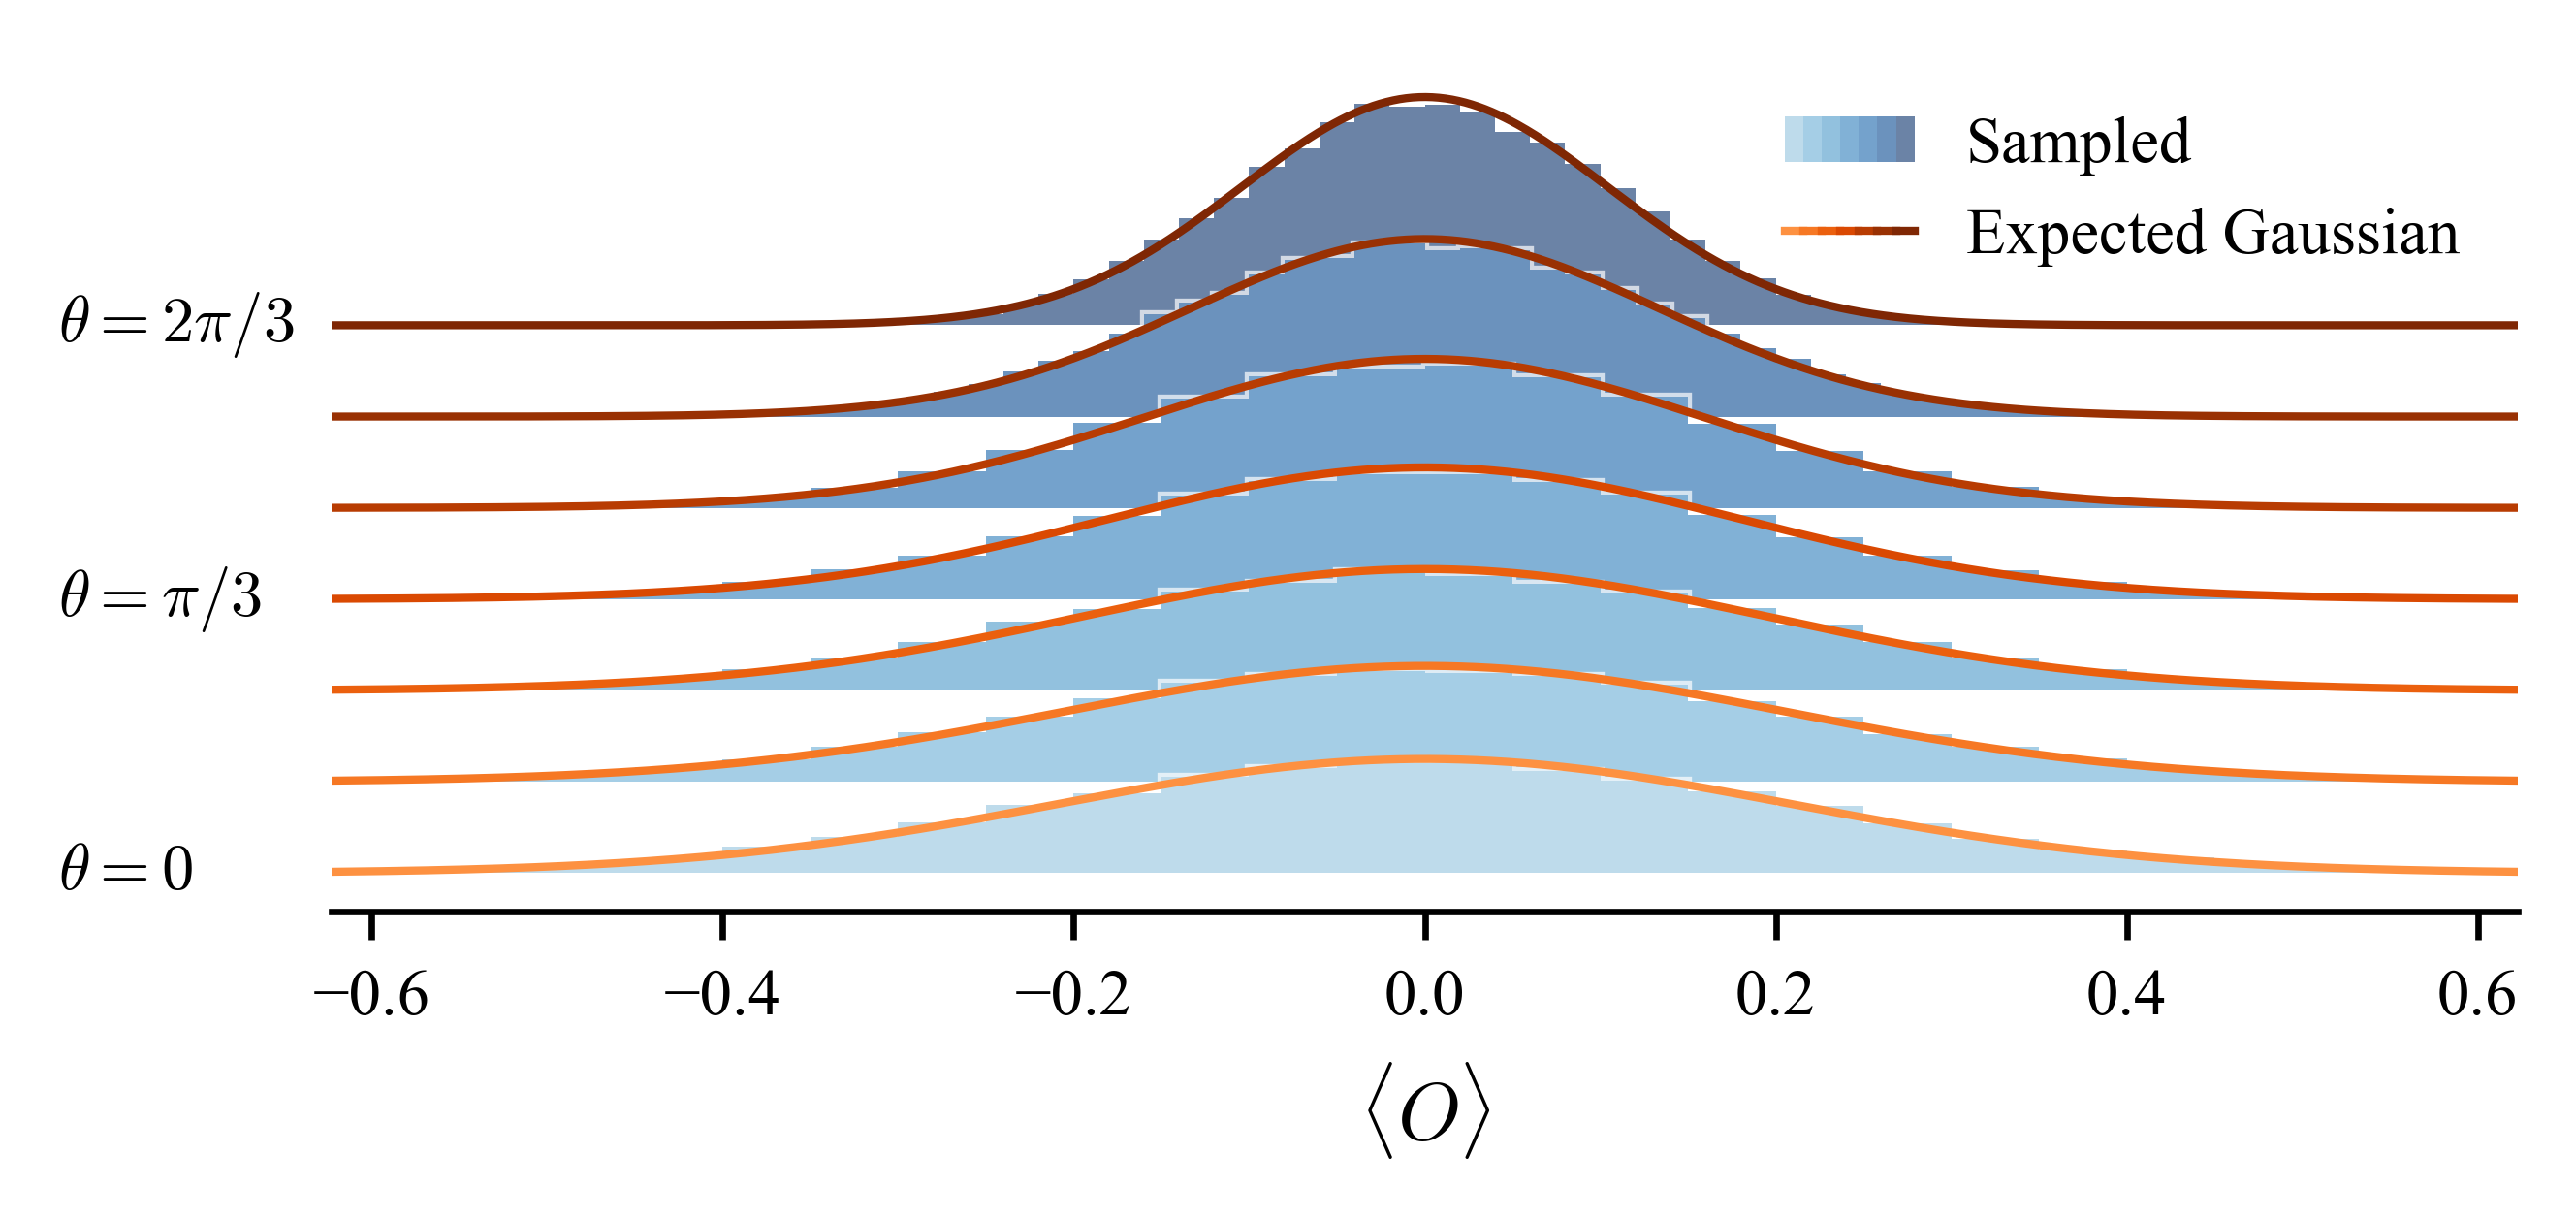

In [25]:
using PyPlot, Printf, Statistics, PyCall, StatsBase

# 1. Calculate the standard deviation of the widest sampled distribution (used only for x-limits)
std_0 = std(jd_samples[1])

# Build the x-grid for the expected Gaussian curves
xgrid = range(-3 * std_0, 3 * std_0; length=1000)

# Precompute expected Gaussian densities:
# mean = 0, variance = exact_variace(n, θ)
expected_densities = zeros(length(thetas), length(xgrid))
for (i, θ) in enumerate(thetas)
    varθ = exact_variace_single(n, θ)
    σθ = sqrt(varθ)
    expected_densities[i, :] .= @. exp(-xgrid^2 / (2 * varθ)) / sqrt(2π * varθ)
end

# Create the figure
fig_width = plot_args["fig_width_inches_full"] * (2/3)
fig, ax = PyPlot.subplots(figsize=(fig_width, 2.2))

d_theta = thetas[2] - thetas[1]
scale_factor = (d_theta * 2.5) / maximum(expected_densities)

# Get a blended transform: X is relative to the axes box (0 to 1), Y is in data coordinates
trans = ax.get_yaxis_transform()
tick_label_size = PyPlot.matplotlib.rcParams["ytick.labelsize"]

for i in 1:length(thetas)
    θ = thetas[i]
    z = length(thetas) - i
    
    # ==========================================
    # A. Calculate and Plot the Raw Histogram
    # ==========================================
    samples = jd_samples[i]
    h = fit(StatsBase.Histogram, samples, nbins=50)
    
    edges = collect(h.edges[1])
    counts = h.weights
    
    # Convert counts to density (Probability Density Function)
    bin_widths = diff(edges)
    density_hist = counts ./ (sum(counts) .* bin_widths)
    
    y_hist = push!(copy(density_hist), density_hist[end]) .* scale_factor
    y_base_hist = fill(θ, length(edges))
    
    # 1. Solid white fill to physically block the lines behind it
    ax.fill_between(
        edges, y_base_hist, y_base_hist .+ y_hist,
        step="post", facecolor="white", zorder=z
    )
    
    # 2. Translucent color gradient for the histograms
    c_hist = PyPlot.matplotlib.cm.Blues(0.3 + 0.7 * (i / length(thetas)))
    ax.fill_between(
        edges, y_base_hist, y_base_hist .+ y_hist,
        step="post", facecolor=c_hist, alpha=0.6, zorder=z
    )

    # 3. Fine white edge line for the histogram bars
    ax.step(
        edges, y_base_hist .+ y_hist,
        where="post", color="white",
        linewidth=1.0, alpha=0.7, zorder=z-0.5,
        solid_joinstyle="miter"
    )

    # ==========================================
    # B. Plot the Expected Gaussian on Top
    # ==========================================
    y_base_gauss = fill(θ, length(xgrid))
    y_gauss = y_base_gauss .+ expected_densities[i, :] .* scale_factor
    
    # Orange gradient for the expected Gaussian curve
    c_gauss = PyPlot.matplotlib.cm.Oranges(0.4 + 0.6 * (i / length(thetas)))
    
    ax.plot(xgrid, y_gauss, color=c_gauss, linewidth=1.0, zorder=z)

    # Add floating text labels every 3rd line (1st, 4th, 7th...)
    if i % 3 == 1
        if θ == 0
            label_str = "\$\\theta = 0\$"
        else
            θ_scaled = 3 * θ / pi
            if isapprox(θ_scaled, round(θ_scaled))
                if θ_scaled == 1
                    label_str = @sprintf("\$\\theta = \\pi/3\$")
                else
                    label_str = @sprintf("\$\\theta = %d\\pi/3\$", round(Int, θ_scaled))
                end
            else
                label_str = @sprintf("\$\\theta = %.2f\\pi/3\$", θ_scaled)
            end
        end

        ax.text(
            -0.125, θ, label_str,
            transform=trans, ha="left", va="center",
            fontsize=tick_label_size, zorder=z+1, clip_on=false
        )
    end
end

# --- Create Custom Legend ---
N = length(thetas)
patches = PyPlot.matplotlib.patches
lines = PyPlot.matplotlib.lines
legend_handler = PyPlot.matplotlib.legend_handler
py_tuple = pybuiltin("tuple")

hist_handles = []
gauss_handles = []

for i in 1:N
    c_h = PyPlot.matplotlib.cm.Blues(0.3 + 0.7 * (i / N))
    c_g = PyPlot.matplotlib.cm.Oranges(0.4 + 0.6 * (i / N))
    
    push!(hist_handles, patches.Patch(facecolor=c_h, alpha=0.6))
    push!(gauss_handles, lines.Line2D([0], [0], color=c_g, linewidth=1.0))
end

tuple_hist = py_tuple(hist_handles)
tuple_gauss = py_tuple(gauss_handles)

ax.legend(
    [tuple_hist, tuple_gauss],
    ["Sampled", "Expected Gaussian"],
    handler_map=Dict(py_tuple => legend_handler.HandlerTuple(ndivide=nothing, pad=0)),
    loc="upper right",
    frameon=false,
    fontsize=tick_label_size
)

# --- Apply Axes Styling ---
ax.set_xlim(-3 * std_0, 3 * std_0)
ax.set_xlabel("\$\\langle O \\rangle\$")

ax.set_yticks([])
ax.set_ylabel("")
ax.spines["left"].set_visible(false)
ax.spines["right"].set_visible(false)
ax.spines["top"].set_visible(false)

fig.tight_layout()
fig

In [26]:
# Save the figure
save_dir = "../plots"
isdir(save_dir) || mkdir(save_dir)
fig.savefig(joinpath(save_dir, "magic_joyplot.pdf"), bbox_inches="tight")